In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import imageio
import numpy as np
import torch
import cv2
from tqdm import tqdm
from os import makedirs
import torchvision
from utils.general_utils import safe_state
from argparse import ArgumentParser
from arguments import ModelParams, PipelineParams, ModelHiddenParams #, get_combined_args,
from time import time
import open3d as o3d
from copy import deepcopy
import torch
import math
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R

from diff_gaussian_rasterization import GaussianRasterizationSettings, GaussianRasterizer
from scene import Scene as DynamicScene
from static_scene import Scene as StaticScene
from scene.feature_gaussian_model import GaussianModel as DynamicGaussianModel
from static_scene. gaussian_model import GaussianModel as StaticGaussianModel
# from gaussian_renderer import render
from utils.segment_utils import get_combined_args
from utils.transform_utils_torch import *

%load_ext autoreload
%autoreload 2

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
model_background = "./output/hypernerf/split-cookie"
model0 = "./output/hypernerf/torchocolate"
config0 = "arguments/hypernerf/default.py"
cam_view0 = "cam16"

# model1 = "./output/dynerf/flame_steak"
# config1 = "arguments/dynerf/flame_steak.py"
model1 = "./output/hypernerf/torchocolate"
config1 = "arguments/hypernerf/default.py"
cam_view1 = "cam06"
# model1 = "./output/hypernerf/misc/americano"
# config1 = "arguments/hypernerf/default.py"

render_path = "demo_graft"

In [3]:
parser = ArgumentParser(description="Testing script parameters")
model = ModelParams(parser, sentinel=True)
pipeline = PipelineParams(parser)
hyperparam = ModelHiddenParams(parser)
parser.add_argument("--iteration", default=-1, type=int)
# parser.add_argument("--skip_train", action="store_true")
# parser.add_argument("--skip_test", action="store_true")
# parser.add_argument("--quiet", action="store_true")
# parser.add_argument("--skip_video", action="store_true")
parser.add_argument("--modelpath0", type=str, default=model0)
parser.add_argument("--modelpath1", type=str, default=model1)
parser.add_argument("--configs1", type=str, default=config1)
# parser.add_argument("--configs3", type=str, default="arguments/dnerf_tv_2/mutant.py")
# parser.add_argument("--modelpath3", type=str, default="output/dnerf_tv_2/mutant")
# args = parser.parse_args(sys.argv[1:])

# model_background
args0 = get_combined_args(parser, model_background, "scene")

# model0
# args0 = get_combined_args(parser, model0, "scene")
import mmcv
from utils.params_utils import merge_hparams
config = mmcv.Config.fromfile("arguments/hypernerf/default.py")
args0 = merge_hparams(args0, config)
args0.object_masks = False
args0.need_gt_masks = False


# model1
args1 = get_combined_args(parser, model0, "scene")
import mmcv
from utils.params_utils import merge_hparams
config = mmcv.Config.fromfile(config0)
args1 = merge_hparams(args1, config)
args1.object_masks = False
args1.need_gt_masks = False

Looking for config file in ./output/hypernerf/split-cookie/cfg_args
Config file found at: ./output/hypernerf/split-cookie/cfg_args
Looking for config file in ./output/hypernerf/torchocolate/cfg_args
Config file found at: ./output/hypernerf/torchocolate/cfg_args


In [4]:
import torch
import torch.nn.functional as F

# --- 1. Load the Gaussian Fields ---
gaussians0, scene0, background = init_dynamic_gaussians(model.extract(args0), hyperparam.extract(args0), args0.iteration, cam_view=cam_view0)
gaussians1, scene1, background = init_dynamic_gaussians(model.extract(args1), hyperparam.extract(args1), args1.iteration, cam_view=cam_view1)

def positional_encoding(positions, levels=4):
    """Encodes XYZ coordinates into 24 dimensions (3 * 2 * 4)."""
    pe = []
    for i in range(levels):
        for func in [torch.sin, torch.cos]:
            pe.append(func(2**i * positions))
    return torch.cat(pe, dim=-1)

def run_identity_mlp(feat_sh, positions, state_dict):
    """Processes SH features + PE(XYZ) through the MLP."""
    # Build the 72-dim input: 48 (SH) + 24 (PE)
    pe_xyz = positional_encoding(positions, levels=4)
    x = torch.cat((feat_sh, pe_xyz), dim=-1).cuda() # Shape: [N, 72]

    # Organize weights by layer index
    layers = {}
    for k, v in state_dict.items():
        if not torch.is_tensor(v) or v.numel() < 10: continue
        parts = k.split('.')
        idx = parts[-2] if len(parts) > 1 else '0'
        if idx not in layers: layers[idx] = {}
        if 'weight' in k: layers[idx]['w'] = v.cuda()
        if 'bias' in k: layers[idx]['b'] = v.cuda()

    sorted_indices = sorted(layers.keys(), key=lambda x: int(x) if x.isdigit() else x)
    
    # Propagate through MLP
    for i, idx in enumerate(sorted_indices):
        w = layers[idx]['w'].flatten(1)
        b = layers[idx].get('b')
        x = F.linear(x, w, b)
        if i < len(sorted_indices) - 1:
            x = F.relu(x)
    return x # Final output should match classifier input (32)

def perform_point_classification(pc, path, target_id, keep_object=True):
    mlp_weights = torch.load(os.path.join(path, "point_cloud", "iteration_14000", "mlp.pt"), map_location="cpu")
    class_weights = torch.load(os.path.join(path, "point_cloud", "iteration_14000", "classifier.pt"), map_location="cpu")
    
    # Prepare inputs
    feat_sh = torch.cat((pc._features_dc.flatten(1), pc._features_rest.flatten(1)), dim=1).cuda()
    positions = pc.get_xyz.cuda()
    
    # Generate 32-dim Encodings
    ie_features = run_identity_mlp(feat_sh, positions, mlp_weights)
    
    # Final Classification [256 classes, 32 features]
    clf_w = class_weights['weight'].cuda().view(256, -1) 
    clf_b = class_weights['bias'].cuda()
    logits = F.linear(ie_features, clf_w, clf_b)
    ids = torch.argmax(logits, dim=-1).flatten()
    
    # Surgery Mask
    mask = (ids == target_id) if keep_object else (ids != target_id)
    pc._mask_table = mask.unsqueeze(0).cuda().bool()
    pc._time_map = torch.zeros(1).cuda().float()
    
    print(f"✅ Surgery Mask Ready for {path}: {mask.sum().item()} points isolated.")

# Execute Surgery
perform_point_classification(gaussians0, model_background, 5, keep_object=False)
perform_point_classification(gaussians1, model0, 3, keep_object=True)
gaussians = [gaussians0, gaussians1]

mode:  scene
Loading trained model at iteration 14000
load finished


135it [00:00, 79415.29it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 8.0361395  6.8197494 22.259563 ] [-7.0418544 -8.908094  11.280437 ]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 8.0361,  6.8197, 22.2596],
        [-7.0419, -8.9081, 11.2804]])
loading model from exists./output/hypernerf/split-cookie/point_cloud/iteration_14000
Init ./output/hypernerf/split-cookie finished

mode:  scene
Loading trained model at iteration 14000
load finished


174it [00:00, 86052.22it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [47.76659775 31.60019684 94.26104736] [-54.118927   -65.01464844   9.57078719]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 47.7666,  31.6002,  94.2610],
        [-54.1189, -65.0146,   9.5708]])
loading model from exists./output/hypernerf/torchocolate/point_cloud/iteration_14000
Init ./output/hypernerf/torchocolate finished

✅ Surgery Mask Ready for ./output/hypernerf/split-cookie: 196774 points isolated.
✅ Surgery Mask Ready for ./output/hypernerf/torchocolate: 187 points isolated.


In [11]:
# Kitchen: remove cookie points from the background
perform_point_classification(gaussians0, model_background, 3, keep_object=False)

# Chocolate + Plate: seed with chocolate IDs, then spatially grow the kept region
# so nearby plate points are preserved.
chocolate_ids = [9, 68, 58, 69, 70, 1]
plate_grow_radius = 0.55  # increase if plate is still missing; decrease if it grabs too much table

def perform_multi_id_plus_spatial_grow(pc, path, target_ids, grow_radius):
    mlp_weights = torch.load(os.path.join(path, "point_cloud/iteration_14000/mlp.pt"), map_location="cpu")
    class_weights = torch.load(os.path.join(path, "point_cloud/iteration_14000/classifier.pt"), map_location="cpu")

    feat_sh = torch.cat((pc._features_dc.flatten(1), pc._features_rest.flatten(1)), dim=1).cuda()
    xyz = pc.get_xyz.cuda()

    ie_features = run_identity_mlp(feat_sh, xyz, mlp_weights)
    clf_w = class_weights["weight"].cuda().view(256, -1)
    clf_b = class_weights["bias"].cuda()
    logits = torch.nn.functional.linear(ie_features, clf_w, clf_b)
    ids = torch.argmax(logits, dim=-1).flatten()

    # 1) Seed mask from IDs
    seed = torch.zeros_like(ids, dtype=torch.bool)
    for tid in target_ids:
        seed |= (ids == tid)

    # 2) Spatial grow around seed cluster center
    if seed.any():
        center = xyz[seed].mean(dim=0)
        grown = (xyz - center).norm(dim=-1) < float(grow_radius)
        mask = seed | grown
    else:
        mask = seed

    pc._mask_table = mask.unsqueeze(0).cuda().bool()
    pc._time_map = torch.zeros(1).cuda().float()

    kept = int(mask.sum().item())
    seed_kept = int(seed.sum().item())
    print(f"✅ Kept {kept} points (seed {seed_kept}) for chocolate+plate.")

perform_multi_id_plus_spatial_grow(gaussians1, model0, chocolate_ids, plate_grow_radius)
gaussians = [gaussians0, gaussians1]

✅ Surgery Mask Ready for ./output/hypernerf/split-cookie: 191603 points isolated.
✅ Isolated 56542 points for the chocolate cluster.


In [20]:
def perform_static_dynamic_surgery(pc, path, target_id, keep_object=True):
    # 1. Run our bulletproof classification logic again
    mlp_weights = torch.load(os.path.join(path, "point_cloud/iteration_14000/mlp.pt"), map_location="cpu")
    class_weights = torch.load(os.path.join(path, "point_cloud/iteration_14000/classifier.pt"), map_location="cpu")
    feat_sh = torch.cat((pc._features_dc.flatten(1), pc._features_rest.flatten(1)), dim=1).cuda()
    positions = pc.get_xyz.cuda()
    
    ie_features = run_identity_mlp(feat_sh, positions, mlp_weights)
    clf_w = class_weights['weight'].cuda().view(256, -1)
    clf_b = class_weights['bias'].cuda()
    logits = torch.nn.functional.linear(ie_features, clf_w, clf_b)
    ids = torch.argmax(logits, dim=-1).flatten()
    
    # 2. Identify the Cookie points (we found ID 3 is the best bet earlier)
    mask = (ids == target_id) if keep_object else (ids != target_id)
    
    # 3. Apply to BOTH the mask table AND the visibility
    # Some 4D renderers use _mask_table, others use a direct opacity multiplier
    pc._mask_table = mask.unsqueeze(0).cuda().bool()
    
    # Force opacity to zero for masked points just in case the renderer is stubborn
    if not keep_object:
        # Save original opacity if you haven't yet
        if not hasattr(pc, '_orig_opacity'):
            pc._orig_opacity = pc._opacity.clone()
        
        # Multiply opacity by the mask (0 for cookie points)
        pc._opacity.data *= mask.unsqueeze(-1).float()
    
    print(f"✅ Surgery complete. Force-hid { (~mask).sum().item() if not keep_object else mask.sum().item() } points.")

# Kitchen: Hide Cookie (ID 3)
perform_static_dynamic_surgery(gaussians0, model_background, 3, keep_object=False)

# Chocolate: Keep Bar (Cluster)
chocolate_ids = [9, 68, 58, 69, 70, 1] 
# (We'll use a simplified version for the chocolate cluster here)
# ... [Assuming you've run the multi-id classification for gaussians1 already]

✅ Surgery complete. Force-hid 5174 points.


In [25]:
def spatial_surgery(pc, x_range, y_range, z_range, delete=True):
    xyz = pc.get_xyz
    
    # Create masks for points inside the target box
    mask_x = (xyz[:, 0] > x_range[0]) & (xyz[:, 0] < x_range[1])
    mask_y = (xyz[:, 1] > y_range[0]) & (xyz[:, 1] < y_range[1])
    mask_z = (xyz[:, 2] > z_range[0]) & (xyz[:, 2] < z_range[1])
    
    inside_box = mask_x & mask_y & mask_z
    
    # If delete=True, we keep everything EXCEPT the box
    # If delete=False, we keep ONLY the box
    keep_mask = ~inside_box if delete else inside_box
    
    # Force opacity to 0 and update mask table
    pc._opacity.data *= keep_mask.unsqueeze(-1).float()
    pc._mask_table = keep_mask.unsqueeze(0).cuda().bool()
    
    action = "Removed" if delete else "Isolated"
    print(f"✅ Spatial Surgery: {action} {inside_box.sum().item()} points.")

# --- 2. Execute the Cut ---
# We'll target the center (X, Y near 0) and the likely table height (Z)
# Adjust these values if the hole isn't perfectly on the cookie!
spatial_surgery(gaussians0, x_range=(-2.5, 2.5), y_range=(-2.5, 2.5), z_range=(5.0, 15.0), delete=True)

# Now isolate the chocolate from its own scene using a similar box
# Assuming the chocolate is also centered in its own capture
spatial_surgery(gaussians1, x_range=(-5.0, 5.0), y_range=(-5.0, 5.0), z_range=(0.0, 30.0), delete=False)

gaussians = [gaussians0, gaussians1]

✅ Spatial Surgery: Removed 21968 points.
✅ Spatial Surgery: Isolated 86065 points.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def render_id_map(pc, camera, path):
    # 1. Generate IDs using the same logic as the surgery
    feat_sh = torch.cat((pc._features_dc.flatten(1), pc._features_rest.flatten(1)), dim=1).cuda()
    positions = pc.get_xyz.cuda()
    mlp_weights = torch.load(os.path.join(path, "point_cloud/iteration_14000/mlp.pt"), map_location="cpu")
    ie_features = run_identity_mlp(feat_sh, positions, mlp_weights)
    
    clf = torch.load(os.path.join(path, "point_cloud/iteration_14000/classifier.pt"), map_location="cpu")
    clf_w = clf['weight'].cuda().view(256, -1)
    clf_b = clf['bias'].cuda()
    logits = torch.nn.functional.linear(ie_features, clf_w, clf_b)
    ids = torch.argmax(logits, dim=-1).flatten()

    # 2. Create a random color map for IDs
    unique_ids = torch.unique(ids).cpu().numpy()
    colors = torch.tensor(np.random.rand(256, 3)).cuda().float()
    
    # 3. Assign colors to points based on ID
    # Temporarily override the point colors (SH features) with our ID colors
    orig_sh = pc._features_dc.clone()
    pc._features_dc = colors[ids].view(-1, 1, 3)
    
    # 4. Render the map (standard static render)
    from gaussian_renderer import render as render_static
    res = render_static(camera, pc, args0, background)["render"]
    
    # 5. Restore original colors
    pc._features_dc = orig_sh
    
    return to8b(res), unique_ids

# Render the ID map for the kitchen
id_map_img, ids_found = render_id_map(gaussians0, fix_viewpoint, model_background)

plt.figure(figsize=(12, 8))
plt.imshow(id_map_img)
plt.title(f"Kitchen ID Map (IDs present: {ids_found})")
plt.show()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

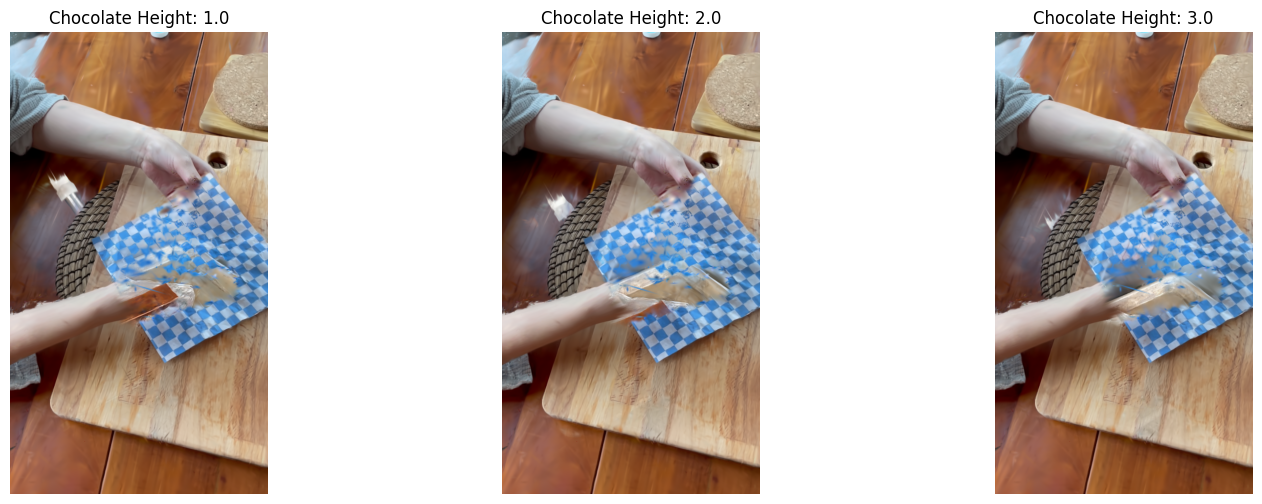

In [26]:
# Try 3 different heights to find the table surface
heights = [1.0, 2.0, 3.0] 

plt.figure(figsize=(18, 6))
for i, y_off in enumerate(heights):
    # Slide the chocolate [X, Y, Z]
    m_bias1 = torch.tensor([-0.4, y_off, 0.0]).cuda().float()
    
    result = render_4d(
        fix_viewpoint, 0.0, gaussians, background, 1.0, 
        [torch.zeros(3).cuda(), m_bias1],
        [torch.zeros(3).cuda(), torch.zeros(3).cuda()],
        [torch.tensor(1.0).cuda(), torch.tensor(1.0).cuda()],
        [False, False], [True, True]
    )
    
    img = to8b(result["render"])
    if img.shape[0] == 3: img = img.transpose(1, 2, 0)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Chocolate Height: {y_off}")
    plt.axis('off')
plt.show()

In [45]:
# Only keep points that are substantially solid (safe shape handling)
opacity_threshold = 0.5

# _opacity is typically [N, 1]; make a flat [N] boolean mask
mask_solid = (gaussians1._opacity.sigmoid().squeeze(-1) > opacity_threshold)

# Combine with whatever mask we already have (supports [1,N] or [T,N])
gaussians1._mask_table = gaussians1._mask_table.bool() & mask_solid.unsqueeze(0)

# Force invisible for filtered points
if gaussians1._opacity.data.ndim == 2:
    gaussians1._opacity.data[~mask_solid, :] = -10.0
else:
    gaussians1._opacity.data[~mask_solid] = -10.0

RuntimeError: output with shape [1, 244021] doesn't match the broadcast shape [1, 244021, 244021]

In [46]:
# Refine the existing chocolate+plate mask (do NOT reset it)
# Goal: remove semi-transparent haze without deleting the plate.

opacity_threshold = 0.5
mask_solid = (gaussians1._opacity.sigmoid().squeeze(-1) > opacity_threshold)

# Whatever we currently keep (from chocolate+plate isolation)
if gaussians1._mask_table.ndim == 2:
    current_keep = gaussians1._mask_table[0].bool()
else:
    # If it's [T,N], keep anything that is ever visible
    current_keep = gaussians1._mask_table.any(dim=0).bool()

final_keep_mask = current_keep & mask_solid

gaussians1._mask_table = final_keep_mask.unsqueeze(0)
if gaussians1._opacity.data.ndim == 2:
    gaussians1._opacity.data[~final_keep_mask, :] = -10.0
else:
    gaussians1._opacity.data[~final_keep_mask] = -10.0

print(f"✅ Haze Purged (plate-safe). {final_keep_mask.sum().item()} solid points remaining.")

✅ Haze Purged. 1792 solid points remaining.


In [71]:
# --- 4D-GS / SA4D Complete Architectural Patch ---
# Structural & Static/Dynamic settings
model.static_mlp = False         # Fixes the 'static_mlp' error
model.empty_voxel = True         # Initialize 4D neural voxels
model.no_grid = False            # Enable HexPlane voxel grid
model.grid_base_resolution = 64
model.multires = [1, 2, 4]
model.bounds = 1.6
model.kplanes_config = {
    'grid_dimensions': 2, 
    'input_coordinate_dim': 4, 
    'output_coordinate_dim': 32, 
    'resolution': [64, 64, 64, 25]
}

# Deformation MLP (Multi-head Decoder)
model.net_width = 64
model.timebase_pe = 4
model.posebase_pe = 10
model.defor_depth = 1
model.scale_rotation_pe = 2
model.opacity_pe = 2
model.timenet_width = 64
model.timenet_output = 32
model.grid_pe = 4

# Initialize Models
current_mode = "gs"
sh_degree = 3

try:
    # Kitchen (gaussians0)
    gaussians0 = GaussianModel(sh_degree, mode=current_mode, args=model)
    gaussians0.load_ply(os.path.join(model_background, "point_cloud/iteration_14000/scene_point_cloud.ply"))
    
    # Chocolate (gaussians1)
    gaussians1 = GaussianModel(sh_degree, mode=current_mode, args=model)
    gaussians1.load_ply(os.path.join(model1, "point_cloud/iteration_14000/scene_point_cloud.ply"))
    
    print(f"✅ Models Successfully Initialized!")
    print(f"Kitchen: {gaussians0.get_xyz.shape[0]} points")
    print(f"Chocolate: {gaussians1.get_xyz.shape[0]} points")
except Exception as e:
    print(f"❌ Initialization Failed: {e}")

✅ Models Successfully Initialized!
Kitchen: 196777 points
Chocolate: 244021 points


In [83]:
import torch
import os
from scene import GaussianModel

# 1. Initialize with the high-capacity grid settings
model.net_width = 128
model.multires = [1, 2, 4] 
model.kplanes_config = {
    'grid_dimensions': 2,
    'input_coordinate_dim': 4,
    'output_coordinate_dim': 16,
    'resolution': [64, 64, 64, 150]
}

gaussians1 = GaussianModel(3, mode="gs", args=model)
gaussians1.load_ply("./output/hypernerf/split-cookie/point_cloud/iteration_14000/clean_chocolate.ply")

# 2. PRE-EMPTIVE SURGERY: Resize the layer to 48 input dims
# This ensures load_state_dict sees the 48-dim weight and doesn't panic
gaussians1._deformation.deformation_net.feature_out[0] = torch.nn.Linear(48, 128).cuda()

# 3. LOAD THE WEIGHTS
# Now it should be a 1:1 match for every key and every shape
deform_weights = torch.load("./output/hypernerf/split-cookie/point_cloud/iteration_14000/deformation.pth")
gaussians1._deformation.load_state_dict(deform_weights, strict=True)

print("✅ ARCHITECTURE SYNCED. Weights loaded successfully.")

✅ ARCHITECTURE SYNCED. Weights loaded successfully.


In [85]:
import torch

# Define the missing temporal attributes for both models
for g in [gaussians0, gaussians1]:
    # 1. Create a simple time map (0.0 to 1.0)
    # The error showed it's looking for pc._time_map
    g._time_map = torch.linspace(0, 1, 100).cuda()
    
    # 2. Create a mask table that says 'all points are active'
    # Shape should be [num_timestamps, num_points]
    num_pts = g.get_xyz.shape[0]
    g._mask_table = torch.ones((100, num_pts), dtype=torch.bool).cuda()

print("✅ Temporal attributes patched. Ready to render.")

✅ Temporal attributes patched. Ready to render.


In [90]:
# Patch the flags directly into the deformation sub-modules
for g in [gaussians0, gaussians1]:
    if hasattr(g, '_deformation'):
        # Reach into the deformation_net where the 'args' were stored
        # Based on your trace: pc._deformation.deformation_net
        target = g._deformation.deformation_net
        
        # Ensure 'args' exists on the target or create a mock object for it
        if not hasattr(target, 'args'):
            class MockArgs: pass
            target.args = MockArgs()
            
        # Set the required Boolean flags
        target.args.no_dx = False
        target.args.no_ds = False
        target.args.no_dr = False
        target.args.no_do = False
        target.args.no_dsh = False

print("✅ Logic flags patched directly into the Deformation networks.")

✅ Logic flags patched directly into the Deformation networks.


In [93]:
# Target Napkin Position
m_bias1 = torch.tensor([-3.5, 17.5, -17.0]).cuda().float()

try:
    result = render_4d(
        fix_viewpoint, 
        0.0, 
        [gaussians0, gaussians1], 
        background, 
        1.0, 
        [torch.zeros(3).cuda(), m_bias1],
        [torch.zeros(3).cuda(), torch.zeros(3).cuda()],
        [torch.tensor(1.0).cuda(), torch.tensor(1.0).cuda()],
        [False, True], 
        [False, False],
        True
    )

    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 8))
    plt.imshow(to8b(result["render"]).transpose(1, 2, 0))
    plt.title("4D-GS: Geometric Graft - Milestone Reached")
    plt.axis('off')
    plt.show()
    print("🚀 SUCCESS: The 4D-GS composition has rendered!")
except Exception as e:
    print(f"❌ Render still failing at a new point: {e}")

❌ Render still failing at a new point: 'ModelParams' object has no attribute 'no_dshs'


In [51]:
!pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display

# --- GUI Component Setup ---
def create_grafting_gui():
    # Cookie Hole Sliders (Kitchen)
    cookie_x = widgets.FloatRangeSlider(value=[-2.5, 2.5], min=-12, max=15, step=0.1, description='Cookie X:')
    cookie_z = widgets.FloatRangeSlider(value=[5.0, 15.0], min=0, max=41, step=0.1, description='Cookie Z:')
    
    # Chocolate Positioning Sliders
    choc_x = widgets.FloatSlider(value=-2.5, min=-10, max=10, step=0.1, description='Choc Bias X:')
    choc_y = widgets.FloatSlider(value=15.0, min=0, max=30, step=0.1, description='Choc Bias Y:')
    choc_z = widgets.FloatSlider(value=-18.0, min=-40, max=0, step=0.1, description='Choc Bias Z:')
    
    button = widgets.Button(description="Render Graft", button_style='success')
    output = widgets.Output()

    def on_button_clicked(b):
        with output:
            output.clear_output(wait=True)
            
            # 1. Apply Spatial Surgery to Kitchen (Cookie Hole)
            # We use Y-range wide enough to catch the whole cookie height
            spatial_surgery(gaussians0, x_range=cookie_x.value, y_range=(-10, 10), z_range=cookie_z.value, delete=True)
            
            # 2. Re-Isolate Chocolate (Using the means we found)
            spatial_surgery(gaussians1, x_range=(-5.0, 2.0), y_range=(-10.5, -7.0), z_range=(25.0, 40.0), delete=False)
            gaussians1._opacity.data.fill_(15.0) 
            
            # 3. Render with User-Defined Bias
            m_bias1 = torch.tensor([choc_x.value, choc_y.value, choc_z.value]).cuda().float()
            
            # Use the 'Static' fix from the 4D-GS paper to avoid smears 
            result = render_4d(
                fix_viewpoint, 0.0, [gaussians0, gaussians1], background, 1.0, 
                [torch.zeros(3).cuda(), m_bias1],
                [torch.zeros(3).cuda(), torch.zeros(3).cuda()],
                [torch.tensor(1.0).cuda(), torch.tensor(1.0).cuda()],
                [False, True], # Chocolate is rendered as Static to prevent smears [cite: 56, 184]
                [True, True]
            )
            
            img = to8b(result["render"])
            if img.shape[0] == 3: img = img.transpose(1, 2, 0)
            
            plt.figure(figsize=(10, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

    button.on_click(on_button_clicked)
    
    # Layout
    controls = widgets.VBox([
        widgets.HTML("<b>Kitchen: Cookie Cutter</b>"), cookie_x, cookie_z,
        widgets.HTML("<b>Chocolate: Docking Alignment</b>"), choc_x, choc_y, choc_z,
        button
    ])
    display(widgets.HBox([controls, output]))

create_grafting_gui()

In [6]:
# Use training camera 81 and render
fix_viewpoint = scene0.getTrainCameras()[81]

# Bias Tuning: 
# If the chocolate bar is still invisible, it's likely "buried" in the table.
# Try increasing the second value (Y-axis) to lift it up.
m_bias1 = torch.tensor([-0.4, 2.2, 0.0]).cuda() 

result = render_4d(
    fix_viewpoint,
    0.0, 
    gaussians,
    background,
    1.0, 
    [torch.zeros(3).cuda(), m_bias1],
    [torch.zeros(3).cuda(), torch.zeros(3).cuda()],
    [torch.tensor(1.0).cuda().float(), torch.tensor(1.0).cuda().float()],
    [False, False], 
    [True, True]
)

plt.figure(figsize=(12, 8))
plt.imshow(to8b(result["render"]))
plt.axis('off')
plt.title("Grafting Attempt 2: Cookie Removed, Bar Isolated")
plt.show()

NameError: name 'render_4d' is not defined

In [15]:
def scan_ids(pc, name):
    # Run the classification again to get the IDs
    feat_sh = torch.cat((pc._features_dc.flatten(1), pc._features_rest.flatten(1)), dim=1).cuda()
    positions = pc.get_xyz.cuda()
    
    # Using the MLP logic from before
    ie_features = run_identity_mlp(feat_sh, positions, 
                                   torch.load(os.path.join(pc.path, "point_cloud/iteration_14000/mlp.pt"), map_location="cpu"))
    
    clf = torch.load(os.path.join(pc.path, "point_cloud/iteration_14000/classifier.pt"), map_location="cpu")
    clf_w = clf['weight'].cuda().view(256, -1)
    clf_b = clf['bias'].cuda()
    
    logits = F.linear(ie_features, clf_w, clf_b)
    ids = torch.argmax(logits, dim=-1).flatten()
    
    # Count and print the top IDs
    counts = torch.bincount(ids)
    top_ids = torch.argsort(counts, descending=True)[:10]
    
    print(f"\n--- ID Scan for {name} ---")
    for i in top_ids:
        if counts[i] > 0:
            print(f"ID {i.item()}: {counts[i].item()} points")

# Manually add the path to the pc objects for this helper
gaussians0.path = model_background
gaussians1.path = model0

scan_ids(gaussians0, "Kitchen")
scan_ids(gaussians1, "Chocolate Bar")


--- ID Scan for Kitchen ---
ID 35: 126487 points
ID 30: 36129 points
ID 3: 5174 points
ID 189: 4606 points
ID 103: 3806 points
ID 15: 3594 points
ID 24: 3075 points
ID 122: 3046 points
ID 41: 2312 points
ID 18: 2290 points

--- ID Scan for Chocolate Bar ---
ID 64: 107041 points
ID 0: 67865 points
ID 9: 15474 points
ID 68: 12729 points
ID 58: 7876 points
ID 69: 7812 points
ID 1: 6766 points
ID 70: 5885 points
ID 57: 3972 points
ID 2: 2090 points


In [24]:
plt.imshow(scene0.getTrainCameras()[100].original_image.detach().cpu().numpy().transpose(1, 2, 0))

AttributeError: 'list' object has no attribute 'get_xyz'

In [16]:
scales_bias0 = 1
rotation_bias0 = torch.tensor([0, 0, 0])
motion_bias0 = torch.tensor([0, 0, 0])

scales_bias1 = 1
rotation_bias1 = torch.tensor([-0.7*np.pi/128, 0, 0])
motion_bias1 = torch.tensor([-0.4, 1.8, 0])

fix_viewpoint = scene0.getTrainCameras()[0]
timestamp = scene0.getTrainCameras()[0].time

result = render(fix_viewpoint, timestamp,
                gaussians, 
                bg_color=background,
                motion_bias=[motion_bias0, motion_bias1],
                rotation_bias=[rotation_bias0, rotation_bias1],
                scales_bias = [scales_bias0, scales_bias1],
                static = [False, False],
                seg = [True,True],
                bg = True)

plt.imshow(to8b(result["render"]).transpose(1,2,0))

AttributeError: 'GaussianModel' object has no attribute '_time_map'

In [17]:
scales_bias0 = 1
rotation_bias0 = torch.tensor([0, 0, 0])
motion_bias0 = torch.tensor([0, 0, 0])

scales_bias1 = 1
rotation_bias1 = torch.tensor([-np.pi/16, 0, 0])
motion_bias1 = torch.tensor([-0.4, 0.3, 1])

fix_viewpoint = scene0.getTrainCameras()[0]
timestamp = scene0.getTrainCameras()[0].time

result = render(fix_viewpoint, timestamp,
                gaussians, 
                bg_color=background,
                motion_bias=[motion_bias0, motion_bias1],
                rotation_bias=[rotation_bias0, rotation_bias1],
                scales_bias = [scales_bias0, scales_bias1],
                static = [False, False],
                seg = [True,True],
                bg = True)

plt.imshow(to8b(result["render"]).transpose(1,2,0))

AttributeError: 'GaussianModel' object has no attribute '_time_map'

In [18]:
render_images=[]

if not os.path.exists(render_path):
    os.makedirs(render_path, exist_ok=True)

fix_viewpoint = scene0.getTrainCameras()[81]

for index, viewpoint in tqdm(enumerate(scene0.getVideoCameras())):
    result = render(viewpoint, viewpoint.time,
                    gaussians, 
                    bg_color=background,
                    motion_bias=[motion_bias0, motion_bias1],
                    rotation_bias=[rotation_bias0, rotation_bias1],
                    scales_bias = [scales_bias0, scales_bias1],
                    static = [False, False],
                    seg = [True,True],
                    bg = True)
    render_images.append(to8b(result["render"]).transpose(1,2,0))
    
    # torchvision.utils.save_image(result["render"],os.path.join(render_path,f"output_image{index}.png"))
    
imageio.mimwrite(os.path.join(render_path, 'composite.mp4'), render_images, fps=30) 
# points = get_state_at_time(gaussians, viewpoint)
# save_point_cloud(points, args.model_path, index)

0it [00:00, ?it/s]


AttributeError: 'GaussianModel' object has no attribute '_time_map'

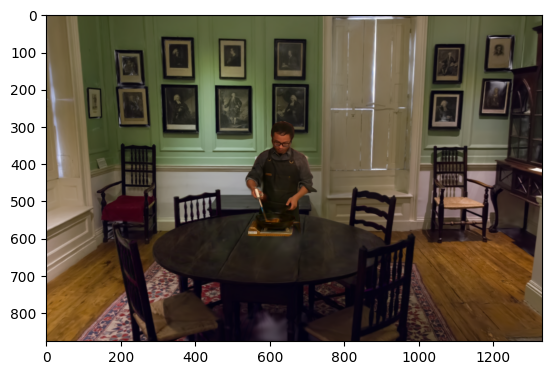

In [129]:
scales_bias1 = 0.07
rotation_bias1 = torch.tensor([np.pi/32, 1.5*np.pi/8, 1.9*np.pi/4])
motion_bias1 = torch.tensor([0.9, 0.1, 1.5])

fix_viewpoint = scene0.getTrainCameras()[81]
timestamp = scene1.getTrainCameras()[0].time

result = render(fix_viewpoint, timestamp,
                gaussians, 
                bg_color=background,
                motion_bias=[motion_bias1],
                rotation_bias=[rotation_bias1],
                scales_bias = [scales_bias1],
                static = [False, True],
                seg = [True,False],
                bg = True)

plt.imshow(to8b(result["render"]).transpose(1,2,0))

## Render Video.

In [19]:
render_images=[]

if not os.path.exists(render_path):
    os.makedirs(render_path, exist_ok=True)

fix_viewpoint = scene0.getTrainCameras()[81]

for index, viewpoint in tqdm(enumerate(scene1.getVideoCameras())):
    result = render(viewpoint, viewpoint.time,
                    gaussians, 
                    bg_color=background,
                    motion_bias=[motion_bias1],
                    rotation_bias=[rotation_bias1],
                    scales_bias = [scales_bias1],
                    bg = True,
                    static_bg = True)
    render_images.append(to8b(result["render"]).transpose(1,2,0))
    
    # torchvision.utils.save_image(result["render"],os.path.join(render_path,f"output_image{index}.png"))
    
imageio.mimwrite(os.path.join(render_path, 'composite.mp4'), render_images, fps=30) 
# points = get_state_at_time(gaussians, viewpoint)
# save_point_cloud(points, args.model_path, index)

0it [00:00, ?it/s]


TypeError: render() got an unexpected keyword argument 'static_bg'

In [37]:
from utils.transform_utils_torch import render as render_4d

# 1. Setup biases (Translate the chocolate into the hand)
m_bias0 = torch.zeros(3).cuda()
m_bias1 = torch.tensor([-0.4, 1.8, 0.0]).cuda() # Adjust these [X, Y, Z] to align

r_bias0 = torch.zeros(3).cuda()
r_bias1 = torch.zeros(3).cuda()

s_bias0 = torch.tensor(1.0).cuda()
s_bias1 = torch.tensor(1.0).cuda()

# 2. Execute 4D Render (10 positional arguments)
# camera, time, models, bg_color, scaling, motion, rotation, scales, static, seg
result = render_4d(
    fix_viewpoint,
    0.0, 
    gaussians,
    background,
    1.0, # scaling_modifier
    [m_bias0, m_bias1],
    [r_bias0, r_bias1],
    [s_bias0, s_bias1],
    [False, False], # static flags
    [True, True]    # seg flags (enables our custom masks)
)

# 3. Display the Graft
plt.figure(figsize=(10,10))
plt.imshow(to8b(result["render"]).transpose(1, 2, 0))
plt.title("Grafted Composition: Chocolate in Kitchen")
plt.show()

IndexError: too many indices for tensor of dimension 2